In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import calendar

In [6]:
customers={
    'customer_id':np.arange(1,201),
    'age':np.random.randint(18, 40, 200),
    'gender':np.random.choice(['Male', 'Female'], 200),
    'city':np.random.choice(['Mumbai', 'Pune', 'Lucknow', 'Jaipur', 'Surat', 'Bhopal', 'Indore'], 200),
}
months=list(calendar.month_name)[1:]
df1=pd.DataFrame(customers)

In [7]:
orders={
    'order_id':np.arange(1, 1001),
    'customer_id':np.random.choice(customers['customer_id'], 1000),
    'prod_category':np.random.choice(['elec', 'toy', 'beauty'], 1000),
    'quantity':np.random.randint(1,10, 1000),
    'price':np.random.randint(699, 2999, 1000),
    'order_month':np.random.choice(months, 1000)
}
df2=pd.DataFrame(orders)

In [8]:
products={
    'prod_category':['elec', 'toy', 'beauty'],
    'profit_margin':[0.25, 0.40, 0.5]
}
df3=pd.DataFrame(products)

In [9]:
df4=pd.merge(df1, df2)

In [10]:
dff=pd.merge(df3, df4)


In [11]:
dff['revenue']=dff['quantity']*dff['price']
dff

,prod_category,profit_margin,customer_id,age,gender,city,order_id,quantity,price,order_month,revenue
0,elec,0.25,1,30,Male,Bhopal,116,8,2601,September,20808
1,elec,0.25,1,30,Male,Bhopal,684,8,1581,September,12648
2,elec,0.25,1,30,Male,Bhopal,891,2,949,July,1898
3,elec,0.25,2,21,Female,Jaipur,605,3,1631,February,4893
4,elec,0.25,2,21,Female,Jaipur,634,1,1724,February,1724
...,...,...,...,...,...,...,...,...,...,...,...
995,beauty,0.50,198,31,Female,Bhopal,497,6,964,January,5784
996,beauty,0.50,198,31,Female,Bhopal,636,7,925,December,6475
997,beauty,0.50,198,31,Female,Bhopal,864,6,1881,May,11286
998,beauty,0.50,199,30,Male,Indore,46,4,2219,October,8876


In [12]:
revenue_pivot=pd.pivot_table(
        dff,
        values='revenue',
        index='order_month',
        columns='prod_category',
        aggfunc='sum'
    )
revenue_pivot

prod_category,beauty,elec,toy
order_month,,,
April,318886,246740,314767
August,212760,275968,268652
December,236854,362921,176024
February,163391,274667,438487
January,216528,329405,265962
July,251995,345127,240675
June,277179,327869,275716
March,229045,171673,225134
May,174426,307894,184538


In [13]:
a=dff.groupby('city')['revenue'].mean()
pd.pivot_table(
    dff,
    index='city',
    values='revenue',
    aggfunc='mean'
)

,revenue
city,
Bhopal,9144.647059
Indore,9182.971154
Jaipur,9909.695122
Lucknow,9707.694611
Mumbai,9291.179775
Pune,9809.982558
Surat,9231.669291


<Axes: xlabel='prod_category', ylabel='order_month'>

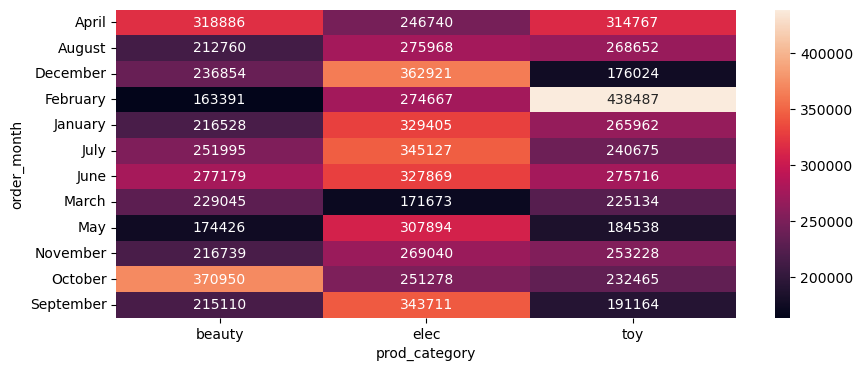

In [17]:
plt.figure(figsize=(10,4))
sns.heatmap(
    revenue_pivot,
    annot=True,
    fmt='.0f'
)

In [18]:
monthly_stats = pd.DataFrame({
    'Month':['Jan','Feb','Mar'],
    'Sales':[1000,1200,1500],
    'Profit':[200,250,350],
    'Orders':[50,60,80]
})

monthly_stats

,Month,Sales,Profit,Orders
0,Jan,1000,200,50
1,Feb,1200,250,60
2,Mar,1500,350,80


In [20]:
melted=pd.melt(
    monthly_stats,
    id_vars='Month',
    var_name='Metric',
    value_name='Value'
)
melted

,Month,Metric,Value
0,Jan,Sales,1000
1,Feb,Sales,1200
2,Mar,Sales,1500
3,Jan,Profit,200
4,Feb,Profit,250
5,Mar,Profit,350
6,Jan,Orders,50
7,Feb,Orders,60
8,Mar,Orders,80
